# Gurney 1983 System with cohort competition : analysis of VP data computed with Mathematica script

In [1]:
from pathlib import Path

DATA_DIR = Path("../data/raw")
FIG_DIR = Path("../figs")

DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

with open(DATA_DIR / "Survey_total_juvenile.csv", newline="") as csvfile:
    ...


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/Survey_total_juvenile.csv'

In [1]:
import numpy as np
from scipy.integrate import odeint, solve_ivp
import matplotlib.pyplot as plt
import wesanderson
import csv
#%matplotlib widget

import seaborn as sns


sns.color_palette("Spectral", as_cmap=False, n_colors = 10)

[(0.8141484044598232, 0.2196847366397539, 0.3048058439061899),
 (0.9330257593233372, 0.3913110342176086, 0.27197231833910035),
 (0.9817762399077278, 0.6073817762399076, 0.3457900807381776),
 (0.9946943483275663, 0.8092272202998846, 0.48696655132641287),
 (0.9982314494425221, 0.9451749327181853, 0.6570549788542868),
 (0.9557862360630527, 0.9823144944252211, 0.6800461361014996),
 (0.8202998846597465, 0.9275663206459055, 0.6126874279123413),
 (0.5910034602076126, 0.835524798154556, 0.6442906574394464),
 (0.3600153787004998, 0.7161860822760476, 0.6655132641291811),
 (0.21299500192233756, 0.5114186851211072, 0.730795847750865)]

# Data extraction from centralized mathematica script of dynamic analysis in a grid of parameters

In [2]:
def extract_value(mathematica_value_string):
    """HANDLE POWER AND / IN MATHEMATICA VALUES"""
    ### HANDLE FRACTIONS
    if len(mathematica_value_string)>50: return 0. # Cleaning artefacts 
    if '/' in mathematica_value_string:
        num, denom = frac_str.split('/')
        try:
            leading, num = num.split(' ')
            whole = float(leading)
        except ValueError:
            whole = 0
        frac = float(num) / float(denom)
        return whole - frac if whole < 0 else whole + frac  
    ### TRY NORMAL FLOAT TRANSF
    try : 
        value = float(mathematica_value_string)
        return value
    except ValueError: # then there is a power 
        nb, exposant = mathematica_value_string.split('*^')
        value = float(nb)*10**(float(exposant))
        return value

def extract_array(list_of_mathematica_values):
    array = np.array([extract_value(mathematica_valuei) for mathematica_valuei in list_of_mathematica_values])
    array = array.astype(float)
    return array

def extractDataXY_Gurney(path_filename, nb_cols):
    """Loads Data.csv with format X,Y,DATA(nb_cols columns) and returns X,Y,GridData ie Data with axis 0:X, axis1:Y"""
    nb_cols = int(nb_cols)
    nb_of_vals = 0
    Yval_nb_found = False
    nb_of_Yvals = 0
    

    ### FILE FIRST ANALYSIS : how many values ? how many Y values per X value?
    with open(path_filename+'.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            if i==0:
                first_Xval = float(row[0])
            if not Yval_nb_found:
                Xval = float(row[0])
                if Xval == first_Xval:
                    nb_of_Yvals +=1
                else:
                    Yval_nb_found = True
            nb_of_vals +=1
    
    # print(nb_of_vals)
    # print(nb_of_kvals)
    nb_of_Xvals = int(nb_of_vals/nb_of_Yvals)
    
    
    ### X, Y extraction
    X_vals = []
    Y_vals = []
    with open(path_filename+'.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            if float(row[0]) not in X_vals:
                X_vals.append(float(row[0]))
            if float(row[1]) not in Y_vals:
                Y_vals.append(float(row[1]))
    X_vals = np.array(X_vals) 
    Y_vals = np.array(Y_vals) 
    

    ### Data extraction into a long array
    Data = np.zeros((nb_of_vals, nb_cols)) #0,1 : Mean, Variance ; 2 : Highest VP.
    with open(path_filename+'.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            Data[i,:] = np.array(extract_array(row[2:]))
    
    ### Data reshaping
    GridData = np.reshape(Data, newshape = ((nb_of_Xvals, nb_of_Yvals, nb_cols)))


    return X_vals, Y_vals, GridData

# Equilibres en fonction de n

La façon dont la variabilité développementale influence les densités à l'équilibre est probablement due à son influence sur $p_{survie}$ d'un juvénile. 
En effet, on a 
$$A* = A_0*ln[\frac{q}{\delta_a} * (f_J)^n] $$
avec
$$f_J = \frac{\theta}{\theta + \delta_j}$$
et on a (preuve simple avec approche stochastique, sinon j'imagine que ça revient à calculer une intégrale avec une fonction gamma dedans):
$$p_{survie} = (\frac{\theta}{\theta + \delta_j})^n$$
d'où
$$A* = A_0*ln[\frac{q}{\delta_a} * p_{survie}] $$


Et comme on paramètre $\theta = n*m_H= \frac{n}{\tau_j}$, $$p_{survie} = (\frac{n*m_H}{n*m_H + \delta_j})^n = (\frac{1}{1 + \frac{\delta_j \tau_j}{n}})^n$$

On voit ainsi bien l'influence de n sur la probabilité de survie du juvénile et donc *in fine* sur les densités à l'équilibre. 

D'ailleurs,
- En formalisme DDE, $ n -> +\inf $ donc $p_{survie} -> e^{-\delta_j \tau_j}$
- En formalisme ODE, $n=1$ donc $p_{survie} = \frac{1}{1+\delta_j \tau_j}$


Et on peut visualiser $p_{survie}$ pour $\delta_j = 0.07, \tau_j  = 20$:


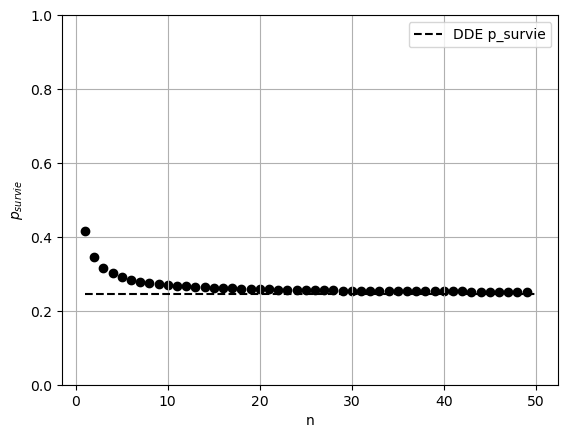

In [3]:
n = np.arange(1,50)

tauJ = 20
theta = n/tauJ

dJ = 0.07

p = (theta/(theta+dJ))**n

plt.scatter(n,p, color = "black")
plt.ylim(0,1)
plt.xlabel("n")
plt.ylabel("$p_{survie}$")
plt.grid(True)
plt.hlines(np.exp(-dJ*tauJ), 1, 50, linestyles = "dashed", color = "black", label = "DDE p_survie")
plt.legend()
plt.show()

## Jeu de paramètres 1 : quasi Nicholson's Blowflies mais avec dj = 0.07 (mortalité des oeufs)

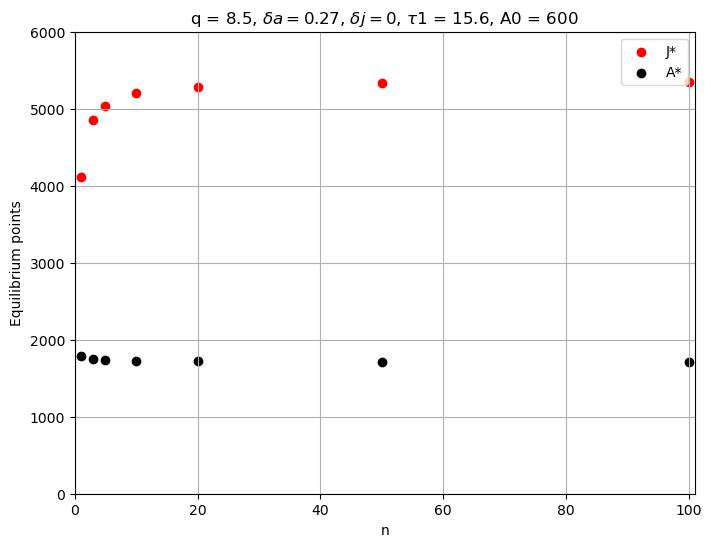

In [4]:
qq = 8.5
daq = 0.27
djq = 0.07
t1q = 15.6
A0q = 600

n_vect = np.array([1, 3, 5, 10, 20, 50, 100]) 
colorsn = sns.color_palette("magma", as_cmap=False, n_colors = len(n_vect))
labels = ["n = "+str(ni) for ni in n_vect]

fJ = (n_vect/qq)/(n_vect/qq + djq)
Aeq = A0q*np.log((qq/daq) * (fJ)**n_vect) 
Jeq = Aeq * (daq/djq) * ((1-(fJ)**n_vect)/((fJ)**n_vect))

fig = plt.figure(figsize = (8,6))
plt.scatter(n_vect, Jeq, color = 'red', label = "J*")
plt.scatter(n_vect, Aeq, color = 'black', label = "A*")
plt.legend()
plt.xlabel("n")  
plt.ylabel("Equilibrium points")
plt.title(r"q = " + str(qq) +
          r", $\delta{a} = $"+str(daq) +
          r", $\delta{j} = $"+str(0) + 
          r", $\tau{1}$ = "+str(t1q) + 
          ", A0 = "+str(A0q)
         )
# plt.yscale("log")
plt.grid(True)
plt.xlim(0,101)
plt.ylim(0,6000)
plt.show()

## Jeu de paramètres 2 : Nicholson's Blowflies (Lucilia cuprina, observed by Nicholson 1954)
 
(pour tau1 : Somme des temps de maturation egg->immature) : 
(pour djq : moyenne pondérée par le temps de résidence des mortalités):
- t1q = 15.6 days
- daq = 0.27 /days
- qq = 8.5
- djq = 0.00576603
- A0q = 600

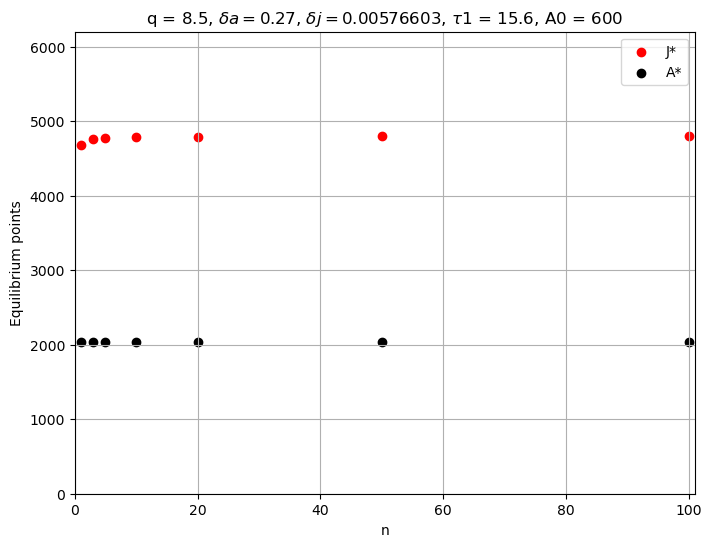

In [5]:
qq = 8.5
daq = 0.27
djq = 0.00576603
t1q = 15.6
A0q = 600

n_vect = np.array([1, 3, 5, 10, 20, 50, 100]) 
colorsn = sns.color_palette("magma", as_cmap=False, n_colors = len(n_vect))
labels = ["n = "+str(ni) for ni in n_vect]

fJ = (n_vect/qq)/(n_vect/qq + djq)
Aeq = A0q*np.log((qq/daq) * (fJ)**n_vect) 
Jeq = Aeq * (daq/djq) * ((1-(fJ)**n_vect)/((fJ)**n_vect))

fig = plt.figure(figsize = (8,6))
plt.scatter(n_vect, Jeq, color = 'red', label = "J*")
plt.scatter(n_vect, Aeq, color = 'black', label = "A*")
plt.legend()
plt.xlabel("n")  
plt.ylabel("Equilibrium points")
plt.title(r"q = " + str(qq) +
          r", $\delta{a} = $"+str(daq) +
          r", $\delta{j} = $"+str(djq) + 
          r", $\tau{1}$ = "+str(t1q) + 
          ", A0 = "+str(A0q)
         )
# plt.yscale("log")
plt.grid(True)
plt.xlim(0,101)
plt.ylim(0,6200)
plt.show()

## Jeu de paramètres 3 : Indian meal-moth (Plodia interpunctella, observed by J.H. Lawton)
- t1q = 28 days
- daq = 0.2 /days
- qq = 9.4 eggs/adult/day
- A0q = 15 moths
- djq = 0 (not taken into account) -> **Eq densities not function of n !**

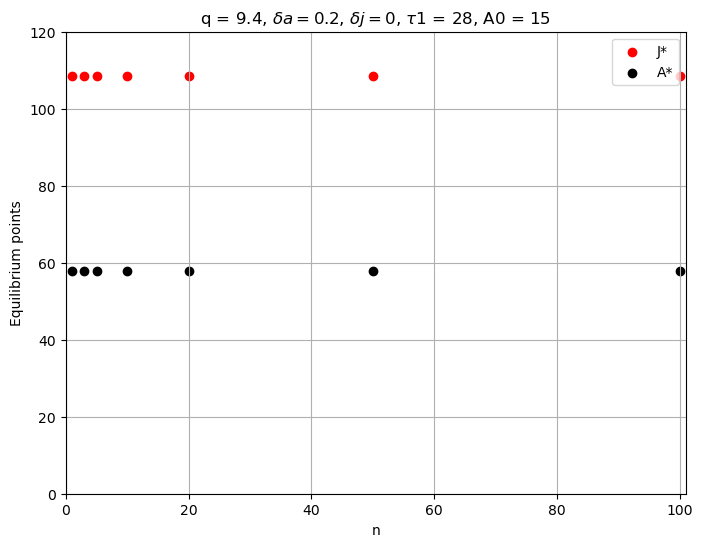

In [6]:
qq = 9.4
daq = 0.2
djq = 0.0000001
t1q = 28
A0q = 15

n_vect = np.array([1, 3, 5, 10, 20, 50, 100]) 
colorsn = sns.color_palette("magma", as_cmap=False, n_colors = len(n_vect))
labels = ["n = "+str(ni) for ni in n_vect]

fJ = (n_vect/qq)/(n_vect/qq + djq)
Aeq = A0q*np.log((qq/daq) * (fJ)**n_vect) 
Jeq = Aeq * (daq/djq) * ((1-(fJ)**n_vect)/((fJ)**n_vect))

fig = plt.figure(figsize = (8,6))
plt.scatter(n_vect, Jeq, color = 'red', label = "J*")
plt.scatter(n_vect, Aeq, color = 'black', label = "A*")
plt.legend()
plt.xlabel("n")  
plt.ylabel("Equilibrium points")
plt.title(r"q = " + str(qq) +
          r", $\delta{a} = $"+str(daq) +
          r", $\delta{j} = $"+str(0) + 
          r", $\tau{1}$ = "+str(t1q) + 
          ", A0 = "+str(A0q)
         )
# plt.yscale("log")
plt.grid(True)
plt.xlim(0,101)
plt.ylim(0,120)
plt.show()

# t1-da plots (Quentin plots)

## Existence curve of non trivial equilibrium
 
On a un équilibre non trivial positif si $$A* = A_0*ln[\frac{q}{\delta_a} * p_{survie}] > 0 $$

ie si $$ \frac{q}{\delta_a} * p_{survie} =\frac{q}{\delta_a} * (\frac{1}{1 + \frac{\delta_j \tau_j}{n}})^n > 1$$

Qu'on peut interpréter comme le nombre moyen de descendants générés par un adulte au cours de sa vie qui ensuite survivent au stade juvénile pour arriver au stade reproducteur.
Ainsi, l'effet de n sur cette existence est positivement dépendant de $\delta_j$ et $\tau_j$.

Il peut se voir sur un graph $\tau_1  - \delta_a$:

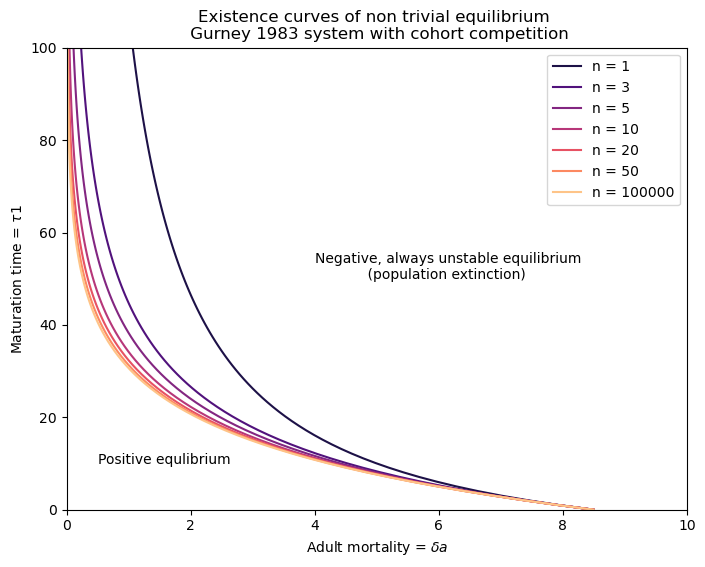

In [7]:
qq = 8.5
daq = 0.27
djq = 0.07
t1q = 15.6
A0q = 600

t1_vect = np.linspace(0.01,100,100) # Will be used on dimension 1 ie as t1_vect[np.newaxis,:]
n_vect = np.array([1, 3, 5, 10, 20, 50, 100000]) # Will be used on dimension 0 ie as n_vect[:,np.newaxis]
d1Curves = qq*((n_vect[:,np.newaxis])/(n_vect[:,np.newaxis]+djq*t1_vect[np.newaxis,:]))**n_vect[:,np.newaxis]

colors = sns.color_palette("magma", as_cmap=False, n_colors = len(n_vect))
labels = ["n = "+str(ni) for ni in n_vect]

plt.figure(figsize = (8,6))
for i,ni in enumerate(n_vect):
    plt.plot(d1Curves[i,:], t1_vect, label = labels[i], color = colors[i])

# plt.plot(daq, t1q, "o", label = "Nicholson's blowflies", color = "green")
# plt.plot(daq, t1q, "o", label = "Lawton's meal moths", color = "blue")

plt.xlim(0,10)
plt.ylim(0,100)
plt.legend()
plt.xlabel(r"Adult mortality = $\delta{a}$")
plt.ylabel(r"Maturation time = $\tau{1}$")
plt.title("Existence curves of non trivial equilibrium \n Gurney 1983 system with cohort competition")
plt.text(4,50, "Negative, always unstable equilibrium \n            (population extinction)")
plt.text(.5,10, "Positive equlibrium")
#plt.xlim(0,1)
plt.show()

On voit que quand $\tau_1$ diminue vers 0 l'écart entre les courbes tend à s'annuler.

On peut aussi voir que si $\delta_j = 0$ alors la positivité de cet équilibre non trivial ne dépend plus ni de $\tau_1$ ni de n:

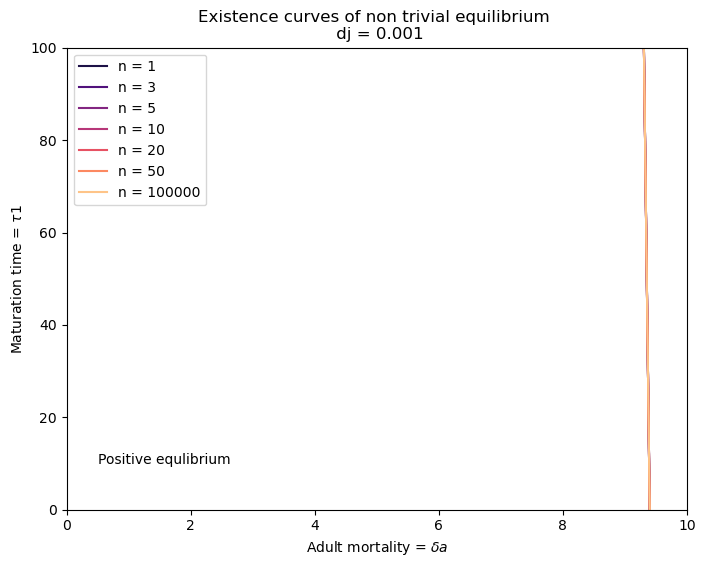

In [8]:
qq = 9.4
daq = 0.2
djq = 0.0001
t1q = 28
A0q = 15

t1_vect = np.linspace(0.01,100,100) # Will be used on dimension 1 ie as t1_vect[np.newaxis,:]
n_vect = np.array([1, 3, 5, 10, 20, 50, 100000]) # Will be used on dimension 0 ie as n_vect[:,np.newaxis]
d1Curves = qq*((n_vect[:,np.newaxis])/(n_vect[:,np.newaxis]+djq*t1_vect[np.newaxis,:]))**n_vect[:,np.newaxis]

colors = sns.color_palette("magma", as_cmap=False, n_colors = len(n_vect))
labels = ["n = "+str(ni) for ni in n_vect]

plt.figure(figsize = (8,6))
for i,ni in enumerate(n_vect):
    plt.plot(d1Curves[i,:], t1_vect, label = labels[i], color = colors[i])

# plt.plot(daq, t1q, "o", label = "Nicholson's blowflies", color = "green")
# plt.plot(daq, t1q, "o", label = "Lawton's meal moths", color = "blue")

plt.xlim(0,10)
plt.ylim(0,100)
plt.legend()
plt.xlabel(r"Adult mortality = $\delta{a}$")
plt.ylabel(r"Maturation time = $\tau{1}$")
plt.title("Existence curves of non trivial equilibrium \n dj = 0.001")
plt.text(.5,10, "Positive equlibrium")
#plt.xlim(0,1)
plt.show()

# Stability plot

## Première version : vue d'ensemble

Cf Script mathematica 1

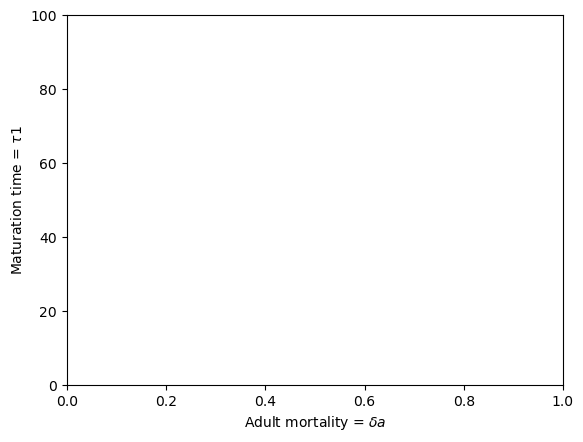

In [8]:
nb_cols = 3
path_filename = 'Gurney_VPTable_n_1q_8.5_dj_0.07_A0_600/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)

Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T

plt.contour(Xmesh,Ymesh,Z, levels = [0], colors = "black")
plt.xlim(0,1)
plt.ylim(0,100)
plt.xlabel(r"Adult mortality = $\delta{a}$")
plt.ylabel(r"Maturation time = $\tau{1}$")
plt.show()


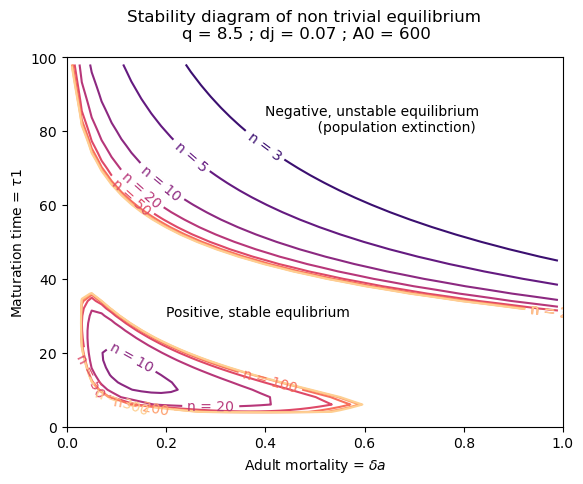

In [9]:
n_vect = np.array([1, 3, 5, 10, 20, 50, 100,200,300]) 
colorsn = sns.color_palette("magma", as_cmap=False, n_colors = len(n_vect))
labels = ["n = "+str(ni) for ni in n_vect]

nb_cols = 3

fig, ax = plt.subplots()
ax.set_xlabel(r"Adult mortality = $\delta{a}$")
ax.set_ylabel(r"Maturation time = $\tau{1}$")
ax.set_xlim(0,1)
ax.set_ylim(0,100)

i = 0
def fmt(x): # Formater function for plt.contour()
    return f"n = {n_vect[i]}"
path_filename = 'Gurney_VPTable_n_1q_8.5_dj_0.07_A0_600/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T
CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i]])
ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i]])

i += 1
def fmt(x): # Formater function for plt.contour()
    return f"n = {n_vect[i]}"
path_filename = 'Gurney_VPTable_n_3q_8.5_dj_0.07_A0_600/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T
CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i]])
ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i]])

i += 1
def fmt(x): # Formater function for plt.contour()
    return f"n = {n_vect[i]}"
path_filename = 'Gurney_VPTable_n_5q_8.5_dj_0.07_A0_600/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T
CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i]])
ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i]])

i += 1
def fmt(x): # Formater function for plt.contour()
    return f"n = {n_vect[i]}"
path_filename = 'Gurney_VPTable_n_10q_8.5_dj_0.07_A0_600/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T
CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i]])
ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i]])

i += 1
def fmt(x): # Formater function for plt.contour()
    return f"n = {n_vect[i]}"
path_filename = 'Gurney_VPTable_n_20q_8.5_dj_0.07_A0_600/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T
CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i]])
ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i]])

i += 1
def fmt(x): # Formater function for plt.contour()
    return f"n = {n_vect[i]}"
path_filename = 'Gurney_VPTable_n_50q_8.5_dj_0.07_A0_600/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T
CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i]])
ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i]])

i += 1
def fmt(x): # Formater function for plt.contour()
    return f"n = {n_vect[i]}"
path_filename = 'Gurney_VPTable_n_100q_8.5_dj_0.07_A0_600/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T
CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i]])
ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i]])

i += 1
def fmt(x): # Formater function for plt.contour()
    return f"n = {n_vect[i]}"
path_filename = 'Gurney_VPTable_n_200q_8.5_dj_0.07_A0_600/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T
CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i]])
ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i]])

i += 1
def fmt(x): # Formater function for plt.contour()
    return f"n = {n_vect[i]}"
path_filename = 'Gurney_VPTable_n_300q_8.5_dj_0.07_A0_600/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T
CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i]])
ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i]])

ax.text(.4,80, "Negative, unstable equilibrium \n            (population extinction)")
plt.text(.2,30, "Positive, stable equlibrium")


fig.suptitle("Stability diagram of non trivial equilibrium \n" + "q = 8.5 ; dj = 0.07 ; A0 = 600")
plt.show()

## Deuxième version : zoom sur la zone intermédiaire d'instabilité (aussi appelée "patate") 

Cf script mathematica 2

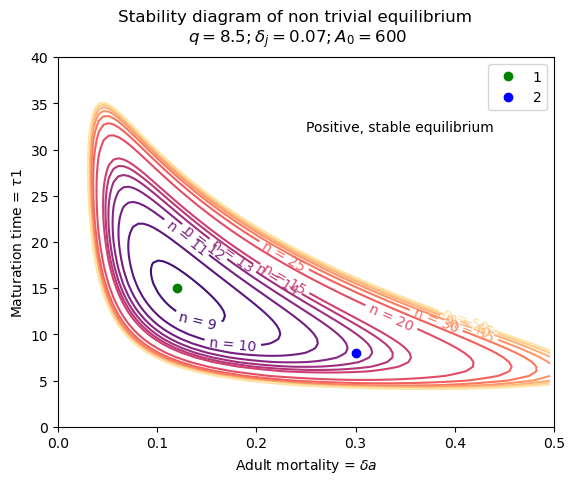

In [10]:
n_vect = np.concatenate((np.arange(1,15+1), np.array([20,25,30,35,40,45,50])))
colorsn = sns.color_palette("magma", as_cmap=False, n_colors = len(n_vect)-5)
labels = ["n = "+str(ni) for ni in n_vect]

nb_cols = 3

fig, ax = plt.subplots()
ax.set_xlabel(r"Adult mortality = $\delta{a}$")
ax.set_ylabel(r"Maturation time = $\tau{1}$")
ax.set_xlim(0,0.5)
ax.set_ylim(0,40)

i = 0
def fmt(x): # Formater function for plt.contour()
    return f"n = {n_vect[i]}"
path_filename = 'Gurney_VPTable_n_1_q_8.5_dj_0.07_A0_600MORE_PRECISE/Gurney_LCT_TableVP'
da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
Z = GridData[:,:,2].T
CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i-5]])
ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i-5]])

for i in range(1,len(n_vect)):
    def fmt(x): # Formater function for plt.contour()
        return f"n = {n_vect[i]}"
    path_filename = f'Gurney_VPTable_n_{n_vect[i]}_q_8.5_dj_0.07_A0_600MORE_PRECISE/Gurney_LCT_TableVP'
    da_vals, t1_vals, GridData = extractDataXY_Gurney(path_filename, nb_cols)
    Xmesh, Ymesh = np.meshgrid(da_vals, t1_vals)
    Z = GridData[:,:,2].T
    CS = ax.contour(Xmesh,Ymesh,Z, levels = [0], colors = [colorsn[i-5]])
    ax.clabel(CS, CS.levels, fmt=fmt, fontsize=10, colors = [colorsn[i-5]])

ax.text(.25,32, "Positive, stable equilibrium")

ax.plot(0.12, 15, "o", color = "green", label = "1")
ax.plot(0.3, 8, "o", color = "blue", label = "2")


ax.legend()
fig.suptitle("Stability diagram of non trivial equilibrium \n" + r"$q = 8.5 ; \delta_j = 0.07 ; A_0 = 600$")
plt.show()

# Simulations en fonction de n 

## Dans la zone d'instabilité ($\delta_a = 0.12 ; \tau_1 = 15$)

In [11]:
def extractSimu_Gurney(path_filename):
    """Loads simulations ran in Mathematica with NDSolve and saved as (t, A(t))"""
    t = []
    Asol = []
    with open(path_filename+'.csv', newline="") as csvfile:
        reader = csv.reader(csvfile)
        for i,row in enumerate(reader):
            t.append(float(row[0]))
            Asol.append(float(row[1]))
    t = np.array(t)
    Asol = np.array(Asol)
    return t, Asol

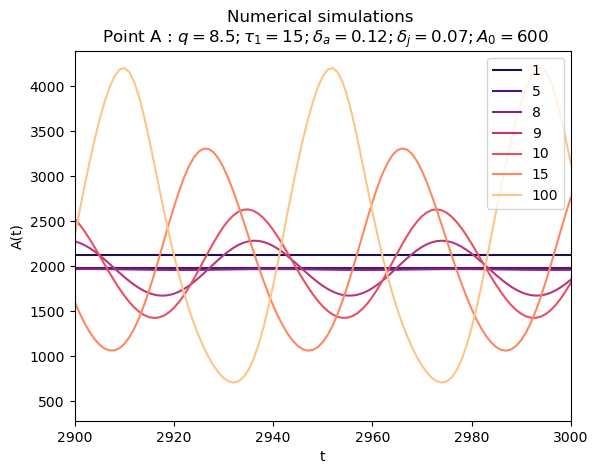

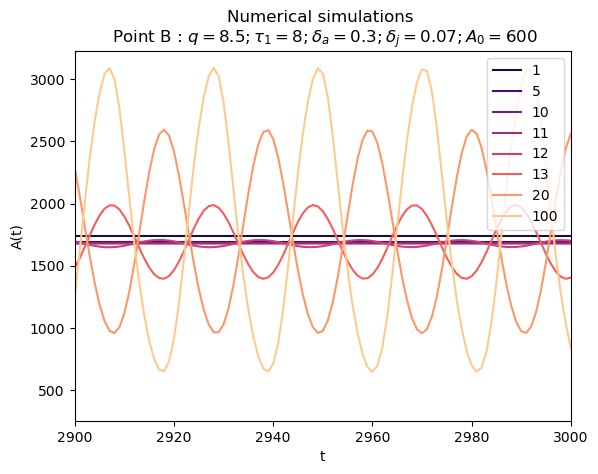

In [12]:
n_vect = [1,5,8,9,10,15,100]
colorsn = sns.color_palette("magma", as_cmap=False, n_colors = len(n_vect))

plt.figure()
for i,ni in enumerate(n_vect):
    path_filename = f"Gurney_Simu_n_{ni}_q_8.5_dj_0.07_A0_600par_A/Gurney_LCT_simu"
    tt, sol = extractSimu_Gurney(path_filename)
    plt.plot(tt, sol, label = str(ni), color = colorsn[i])
plt.xlim(2900,3000)
plt.xlabel("t")
plt.ylabel("A(t)")
plt.legend()
plt.title("Numerical simulations \n Point A : " + r"$ q = 8.5 ; \tau_1 = 15 ; \delta_a = 0.12 ; \delta_j = 0.07 ; A_0 = 600$")
plt.show()

n_vect = [1,5,10,11,12,13,20,100]
colorsn = sns.color_palette("magma", as_cmap=False, n_colors = len(n_vect))

plt.figure()
for i,ni in enumerate(n_vect):
    path_filename = f"Gurney_Simu_n_{ni}_q_8.5_dj_0.07_A0_600par_B/Gurney_LCT_simu"
    tt, sol = extractSimu_Gurney(path_filename)
    plt.plot(tt, sol, label = str(ni), color = colorsn[i])
plt.xlim(2900,3000)
plt.xlabel("t")
plt.ylabel("A(t)")
plt.legend()
plt.title("Numerical simulations \n Point B : " + r"$ q = 8.5 ; \tau_1 = 8 ; \delta_a = 0.3 ; \delta_j = 0.07 ; A_0 = 600$")
plt.show()

## Avec les paramètres de Plodia ventura dans Gurney 1983

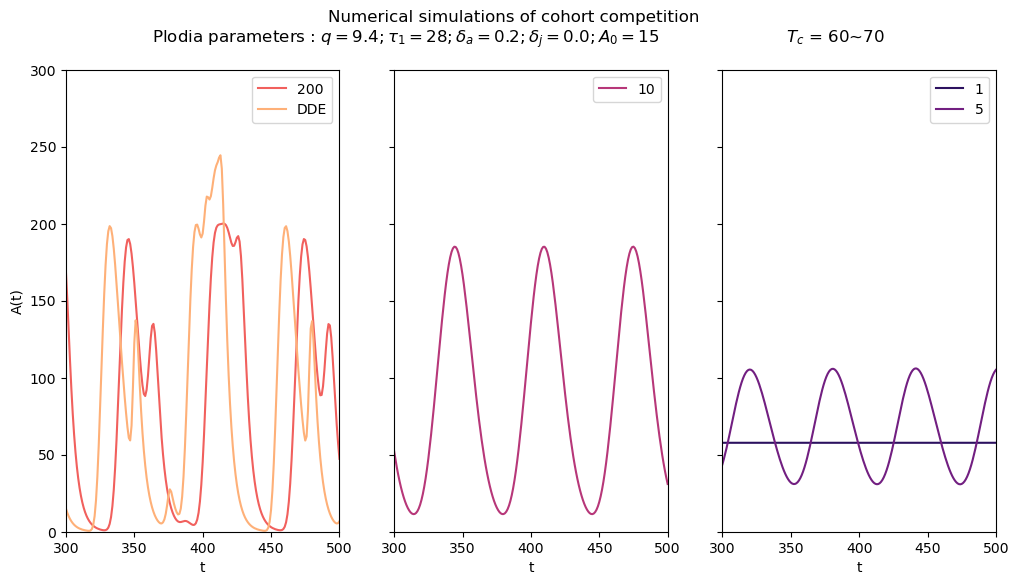

In [13]:
n_vect = [1,5,10,200]
colorsn = sns.color_palette("magma", as_cmap=False, n_colors = len(n_vect)+1)
colors_dict = {f"{ni}": colorsn[i] for i,ni in enumerate(n_vect)}
colors_dict["DDE"] = colorsn[len(n_vect)]

fig, ax = plt.subplots(1,3, figsize = (12,6), sharex=True, sharey=True)

# LCT simu
# Low variability subplot
for i,ni in enumerate(n_vect):
    path_filename = f"Gurney_Simu_n_{ni}_q_9.4_dj_0._A0_15par_Plodia/Gurney_LCT_simu"
    tt, sol = extractSimu_Gurney(path_filename)
    if ni>=100:
        ax[0].plot(tt, sol, label = str(ni), color = colors_dict[str(ni)])
    elif ni>=10:
        ax[1].plot(tt, sol, label = str(ni), color = colors_dict[str(ni)])
    else:
        ax[2].plot(tt, sol, label = str(ni), color = colors_dict[str(ni)])

#DDE simu
path_filename = f"Gurney_Simu_DDE_q_9.4_dj_0._A0_15par_Plodia/Gurney_LCT_simu"
tt, sol = extractSimu_Gurney(path_filename)
ax[0].plot(tt, sol, label = "DDE", color = colorsn[len(n_vect)])

for axi in ax :
    axi.set_ylim(0,300)
    axi.set_xlim(300,500)
    axi.set_xlabel("t")
    axi.legend()
ax[0].set_ylabel("A(t)") 
fig.suptitle("Numerical simulations of cohort competition \n Plodia parameters : " + r"$ q = 9.4 ; \tau_1 = 28 ; \delta_a = 0.2 ; \delta_j = 0.0 ; A_0 = 15$" + "                        $T_c$ = 60~70")
plt.show()

# Approximation manuelle de la période des oscillations sur Mathematica :
#200 : Tc=65
#10 : Tc=65
#5 : Tc=61
# DDE : Tc=65